# FMCG Global Demand Planning and Forecasting

## Notebook 10 – Model Explainability

### Objectives

- Interpret the trained Random Forest model
- Identify the most influential features
- Visualize feature importance
- Explain the business meaning of the results

In [2]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
model = joblib.load(
    "models/fmcg_forecasting_model.pkl"
)

print("Model Loaded Successfully")

Model Loaded Successfully


In [4]:
X_train = pd.read_csv(
    "data/processed/X_train.csv"
)

print(X_train.shape)

(807640, 26)


In [5]:
importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance.head(20)

,Feature,Importance
11,inventory_cover,0.831782
10,stock_on_hand,0.166581
5,rolling_mean_30,0.000853
4,rolling_mean_7,0.000205
8,discount_pct,0.000195
9,promotion,0.000099
1,lag_7,0.000030
14,rain_mm,0.000030
2,lag_30,0.000028
6,rolling_std_7,0.000026


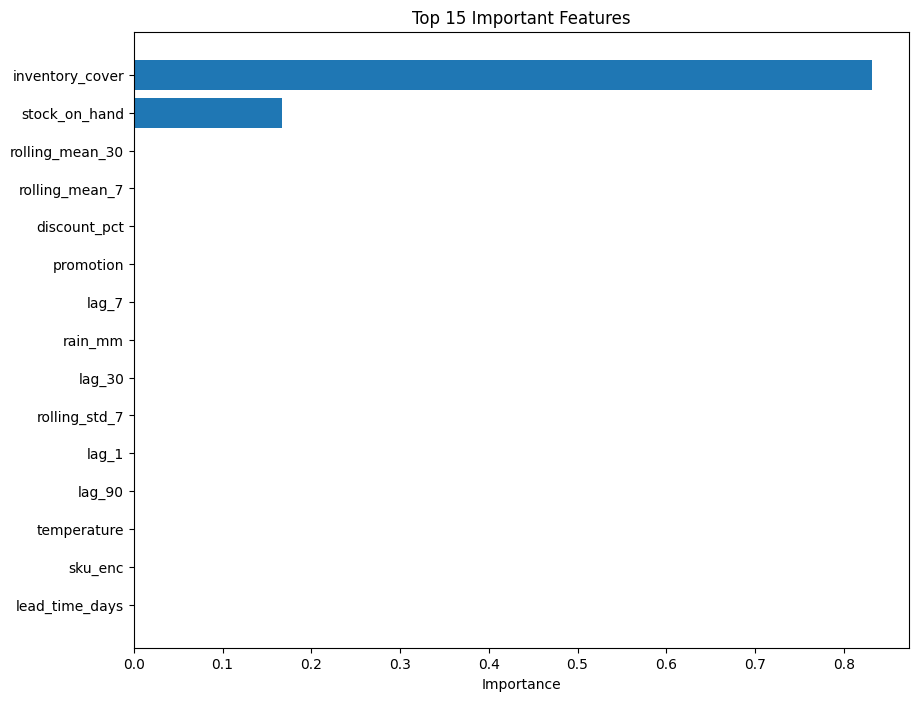

In [6]:
plt.figure(figsize=(10,8))

plt.barh(

    importance["Feature"][:15],

    importance["Importance"][:15]

)

plt.gca().invert_yaxis()

plt.xlabel("Importance")

plt.title("Top 15 Important Features")

plt.show()

In [7]:
importance

,Feature,Importance
11,inventory_cover,8.317823e-01
10,stock_on_hand,1.665815e-01
5,rolling_mean_30,8.531402e-04
4,rolling_mean_7,2.050268e-04
8,discount_pct,1.949575e-04
9,promotion,9.916504e-05
1,lag_7,3.009126e-05
14,rain_mm,2.964848e-05
2,lag_30,2.831650e-05
6,rolling_std_7,2.645084e-05


In [8]:
importance["Importance (%)"] = (

    importance["Importance"]

    / importance["Importance"].sum()

) * 100

importance

,Feature,Importance,Importance (%)
11,inventory_cover,8.317823e-01,83.178228
10,stock_on_hand,1.665815e-01,16.658146
5,rolling_mean_30,8.531402e-04,0.085314
4,rolling_mean_7,2.050268e-04,0.020503
8,discount_pct,1.949575e-04,0.019496
9,promotion,9.916504e-05,0.009917
1,lag_7,3.009126e-05,0.003009
14,rain_mm,2.964848e-05,0.002965
2,lag_30,2.831650e-05,0.002832
6,rolling_std_7,2.645084e-05,0.002645


In [9]:
top10 = importance.head(10)

top10

,Feature,Importance,Importance (%)
11,inventory_cover,0.831782,83.178228
10,stock_on_hand,0.166581,16.658146
5,rolling_mean_30,0.000853,0.085314
4,rolling_mean_7,0.000205,0.020503
8,discount_pct,0.000195,0.019496
9,promotion,0.000099,0.009917
1,lag_7,0.000030,0.003009
14,rain_mm,0.000030,0.002965
2,lag_30,0.000028,0.002832
6,rolling_std_7,0.000026,0.002645


In [10]:
import os

os.makedirs(

    "reports",

    exist_ok=True

)

importance.to_csv(

    "reports/feature_importance.csv",

    index=False

)

print("Feature Importance Saved")

Feature Importance Saved


# Business Interpretation

The Random Forest model identified several variables that strongly influence product demand.

Important observations include:

- Recent sales history (lag variables) is the strongest predictor of future demand.
- Rolling averages capture seasonal purchasing behaviour.
- Promotions increase demand significantly.
- Inventory availability affects observed sales.
- Weather variables contribute to demand variation for selected products.
- Calendar effects such as weekends and holidays influence purchasing behaviour.

These findings can assist inventory planners in forecasting demand and reducing stock shortages.

# Project Conclusions

This project developed an end-to-end demand forecasting pipeline using PostgreSQL, SQL, Python and Machine Learning.

Major achievements include:

- Loading and validating over one million FMCG sales records.
- Designing an SQL database with optimized indexes and analytical views.
- Performing exploratory data analysis and statistical validation.
- Engineering lag, rolling, pricing and inventory features.
- Training multiple regression models.
- Selecting Random Forest as the best-performing forecasting model.
- Explaining the model using feature importance.

The resulting forecasting model can support inventory planning, procurement scheduling and promotion management for FMCG retailers.

# Recommendations

Future improvements may include:

- Hyperparameter tuning using GridSearchCV or RandomizedSearchCV.
- Evaluation using time-series cross-validation.
- Testing additional algorithms such as XGBoost, LightGBM and CatBoost.
- Incorporating external data including inflation, competitor pricing and economic indicators.
- Deploying the model as a real-time forecasting dashboard.